In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
%cd /content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition
!ls
!pip install -r requirements.txt

/content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition
Data  FaceBook_solution_47441466  README.md  requirements.txt
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 1.6 MB/s eta 0:00:00
   ━

/content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/FaceBook_solution_47441466
Exception reporting mode: Verbose
data.x: torch.Size([22470, 4714])
data.y: torch.Size([22470])
test_mask: torch.Size([22470])
Test Accuracy: 0.9568


/content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/FaceBook_solution_47441466/train.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


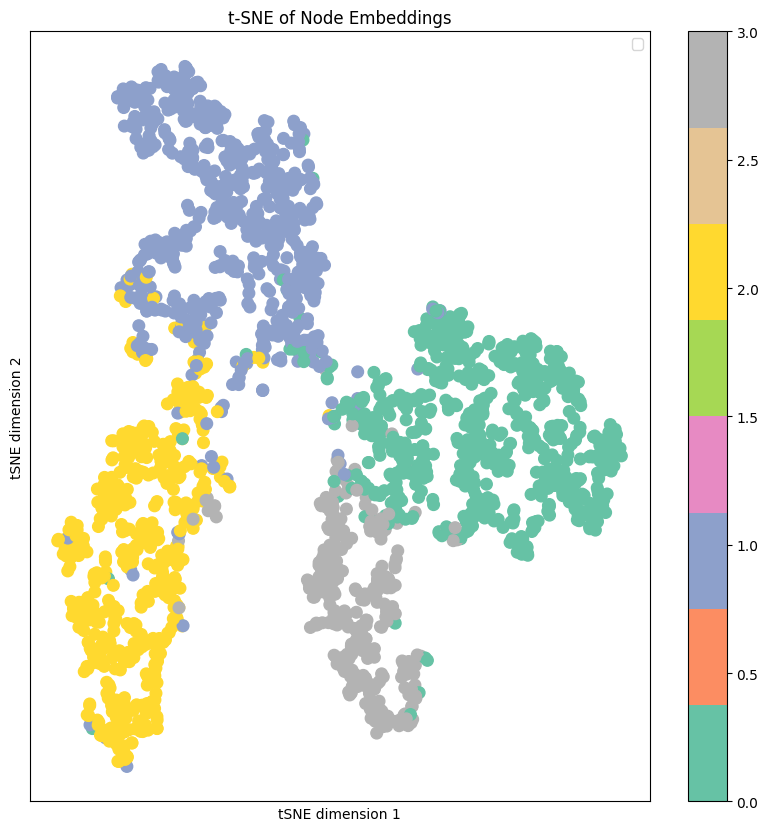

In [1]:
#after training and saving a model, I can load it here and use it for inference.
%cd /content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/FaceBook_solution_47441466
# !ls
%xmode Verbose
# from train import Trainer
# from dataset import FacebookData
# from modules import GCN

# data_path = 'data/facebook_combined.txt'
# model_path = 'models/facebook_gcn.pth'
# output_path = 'results/facebook_inference.txt'
from modules import GCN
import torch
from dataset import FacebookData
from train import Trainer
from config import SEED, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, NUM_EPOCHS
import numpy as np
import random
# Set seed for reproducibility and other boilerplate
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#load data
model_path = "/content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/FaceBook_solution_47441466/Saved_models/model.pth"
data_path = "/content/drive/MyDrive/COMP3710/A3/facebook"

#model parameters are all autocompleted in trainer init based on the data,
#test data is also set up in the model
#instantiate a new model with the weights in the model path weightss
predictor = Trainer(model_path=model_path, data_path_prefix=data_path)


#inference
preds, labels, embeddings = predictor.predict()
# visualise
predictor.visualise(embeddings, labels)

In [6]:
from google.colab import drive
drive.flush_and_unmount()
print('Drive unmounted.')

Drive unmounted.


In [7]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [6]:
%pycat /content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/FaceBook_solution_47441466/predict.py
%pycat /content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/FaceBook_solution_47441466/train.py